In [7]:
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Dict
import math
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import math
from typing import List, Dict
import networkx as nx
import matplotlib.pyplot as plt
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv(override=True)

True

In [8]:
class TokenPredictor:
    def __init__(self, model_name: str = "gpt2"):
        self.model_name = model_name
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForCausalLM.from_pretrained(model_name)
        self.model.eval()

    def predict_tokens(self, prompt: str, max_tokens: int = 30) -> List[Dict]:
        inputs = self.tokenizer(prompt, return_tensors="pt")

        generated = inputs["input_ids"]
        predictions = []

        for _ in range(max_tokens):
            with torch.no_grad():
                outputs = self.model(generated)
                logits = outputs.logits[:, -1, :]

                probs = torch.softmax(logits, dim=-1)

                topk = torch.topk(probs, k=3)

                top_token_id = topk.indices[0][0].item()
                top_prob = topk.values[0][0].item()

                token = self.tokenizer.decode([top_token_id])

                alternatives = []
                for i in range(1, 3):
                    alt_token = self.tokenizer.decode([topk.indices[0][i].item()])
                    alt_prob = topk.values[0][i].item()
                    alternatives.append((alt_token, alt_prob))

                predictions.append({
                    "token": token,
                    "probability": top_prob,
                    "alternatives": alternatives
                })

                next_token = torch.tensor([[top_token_id]])
                generated = torch.cat([generated, next_token], dim=1)

        return predictions


def create_token_graph(model_name: str, predictions: List[Dict]) -> nx.DiGraph:
    """
    Create a directed graph showing token predictions and alternatives.
    """
    G = nx.DiGraph()

    G.add_node("START", token=model_name, prob="START", color="lightgreen", size=4000)

    # First, create all main token nodes in sequence
    for i, pred in enumerate(predictions):
        token_id = f"t{i}"
        G.add_node(
            token_id,
            token=pred["token"],
            prob=f"{pred['probability'] * 100:.1f}%",
            color="lightblue",
            size=6000,
        )

        if i == 0:
            G.add_edge("START", token_id)
        else:
            G.add_edge(f"t{i - 1}", token_id)

    # Then add alternative nodes with a different y-position
    last_id = None
    for i, pred in enumerate(predictions):
        parent_token = "START" if i == 0 else f"t{i - 1}"

        # Add alternative token nodes slightly below main sequence
        for j, (alt_token, alt_prob) in enumerate(pred["alternatives"]):
            alt_id = f"t{i}_alt{j}"
            G.add_node(
                alt_id, token=alt_token, prob=f"{alt_prob * 100:.1f}%", color="lightgray", size=6000
            )

            # Add edge from main token to its alternatives only
            G.add_edge(parent_token, alt_id)
            last_id = parent_token

    G.add_node("END", token="END", prob="100%", color="red", size=6000)
    G.add_edge(last_id, "END")

    return G


def visualize_predictions(G: nx.DiGraph, figsize=(14, 80)):
    """
    Visualize the token prediction graph with vertical layout and alternating alternatives.
    """
    plt.figure(figsize=figsize)

    # Create custom positioning for nodes
    pos = {}
    spacing_y = 5  # Vertical spacing between main tokens
    spacing_x = 5  # Horizontal spacing for alternatives

    # Position main token nodes in a vertical line
    main_nodes = [n for n in G.nodes() if "_alt" not in n]
    for i, node in enumerate(main_nodes):
        pos[node] = (0, -i * spacing_y)  # Center main tokens vertically

    # Position alternative nodes to left and right of main tokens
    for node in G.nodes():
        if "_alt" in node:
            main_token = node.split("_")[0]
            alt_num = int(node.split("_alt")[1])
            if main_token in pos:
                # Place first alternative to left, second to right
                x_offset = -spacing_x if alt_num == 0 else spacing_x
                pos[node] = (x_offset, pos[main_token][1] + 0.05)

    # Draw nodes
    node_colors = [G.nodes[node]["color"] for node in G.nodes()]
    node_sizes = [G.nodes[node]["size"] for node in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes)

    # Draw all edges as straight lines
    nx.draw_networkx_edges(G, pos, edge_color="gray", arrows=True, arrowsize=20, alpha=0.7)

    # Add labels with token and probability
    labels = {node: f"{G.nodes[node]['token']}\n{G.nodes[node]['prob']}" for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, font_size=14)

    plt.title("Token prediction.")
    plt.axis("off")

    # Adjust plot limits to ensure all nodes are visible
    margin = 8
    x_values = [x for x, y in pos.values()]
    y_values = [y for x, y in pos.values()]
    plt.xlim(min(x_values) - margin, max(x_values) + margin)
    plt.ylim(min(y_values) - margin, max(y_values) + margin)

    # plt.tight_layout()
    return plt


# The Mechanics of Next Token Prediction


*how LLMs actually generate text, often described as a "multi-step process"*:


**Probabilistic Output:** Transformers do not just output a word; they produce a set of probabilities for every possible next token (often up to 128,000 possibilities).

**The Inference Loop:** To generate a sentence, the model selects a token (usually the most likely one), appends it to the original input sequence, and passes the entire new sequence back into the model to predict the subsequent token

**Statistical Nature:** models are essentially statistical prediction machines that maintain consistency by ensuring new tokens align with the patterns of prior tokens

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:  99%|#########9| 545M/548M [00:00<?, ?B/s]

c:\Users\HP\Desktop\LLM_ENGINEERING\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\HP\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

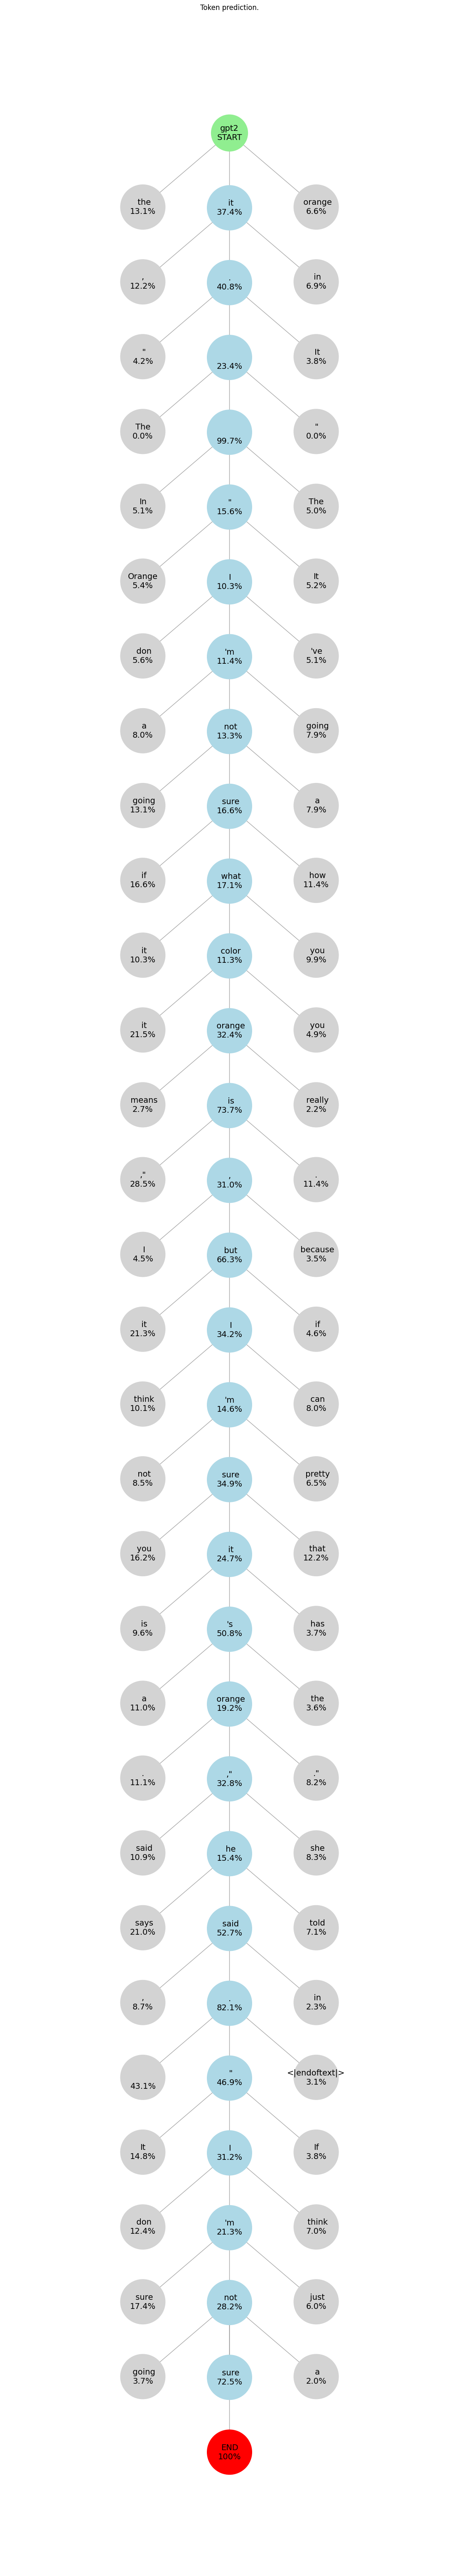

In [9]:
message = "In one sentence, describe the color orange to someone who has never been able to see"
model_name = "gpt2"

predictor = TokenPredictor(model_name)
predictions = predictor.predict_tokens(message)
G = create_token_graph(model_name, predictions)
plt = visualize_predictions(G)
plt.show()

In [ ]:
from visualizer import TokenPredictor, create_token_graph, visualize_predictions

message = "In one sentence, describe the color orange to someone who has never been able to see"
model_name = "gpt2"

predictor = TokenPredictor(model_name)
predictions = predictor.predict_tokens(message)
G = create_token_graph(model_name, predictions)
plt = visualize_predictions(G)
plt.show()

# Understanding Temperature
The technical implementation of "temperature," is a common setting in LLM APIs:

**Temperature = 0:** The model is highly consistent and always selects the token with the highest probability

**Higher Temperature:** The model samples from a wider range of tokens. While more probable tokens are still favored, a higher temperature allows the model to select lower-probability tokens, resulting in more variety or "imaginative" responses